# Analysis of Grammatical Voice Effect on Wording Change Detection

This notebook analyzes experimental data to test the hypothesis that **passive sentences** lead to better encoding of surface structure, resulting in higher accuracy for detecting wording changes compared to **active sentences**.

**Hypothesis:**
> The grammatical voice of a sentence determines its storage mechanism. Because passive sentences are less common and less fluent, they act as a cognitive "speed bump" (a desirable difficulty) that forces the brain to explicitly encode the surface structure. Consequently, participants will be more accurate at detecting wording changes in passive sentences than in active sentences.

**Experimental Design:**
- **Study Phase:** Participants view sentences in either Active (_A) or Passive (_P) voice.
- **Test Phase:** Participants view the sentence again. It is either Identical (Same Voice) or Transformed (Opposite Voice).
- **Task:**
    1. Press Spacebar (IR) if they recognize the sentence content.
    2. Press Yes/No (WR) to indicate if the wording is identical or changed.
- **Key Metric:** Accuracy of the Wording Recognition (WR) response.

In [2]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Define path to log files
log_path = 'NewLogsAnonymized'
log_pattern = os.path.join(log_path, '*.log')

# Find all log files
all_files = glob.glob(log_pattern)
print(f'Found {len(all_files)} log files.')

Found 114 log files.


In [3]:
# Load and concatenate all participant log files
df_list = []

for filename in all_files:
    try:
        df = pd.read_csv(filename, on_bad_lines='skip')
        df_list.append(df)
    except Exception as e:
        print(f'Error reading {filename}: {e}')

if df_list:
    raw_data = pd.concat(df_list, axis=0, ignore_index=True)
    print(f'Successfully loaded {len(raw_data)} rows from {len(df_list)} files.')
else:
    print('No data loaded.')
    raw_data = pd.DataFrame()

# Remove all practice events (Event starts with "Practice")
practice_mask = raw_data['Event'].str.startswith('Practice', na=False)
print(f'Removing {practice_mask.sum()} practice events.')
raw_data = raw_data[~practice_mask].reset_index(drop=True)

print(f'Rows after removing practice events: {len(raw_data)}')
print(f'Unique events: {raw_data["Event"].unique()}')
raw_data.head()

Successfully loaded 81329 rows from 114 files.
Removing 5269 practice events.
Rows after removing practice events: 76060
Unique events: <ArrowStringArray>
[             'Sentence shown',                    'gap_time',
 'Validation Wrong IR pressed',                  'IR pressed',
                  'WR pressed',       'Validation IR pressed',
          'Rest Phase started',           'Validation Missed']
Length: 8, dtype: str


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR
0,232,1770219378184,Sentence shown,HF_29_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,232,1770219382186,gap_time,NaN,NaN,NaN,NaN,GapTime_1289,NaN,NaN,NaN,NaN,NaN,NaN
2,232,1770219383476,Sentence shown,HF_9_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232,1770219387478,gap_time,NaN,NaN,NaN,NaN,GapTime_1108,NaN,NaN,NaN,NaN,NaN,NaN
4,232,1770219388587,Sentence shown,HF_24_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning and Feature Engineering

We reconstruct the trial pairs (Study -> Test) to identify the **Original Voice** for each test trial.

Steps:
1. Extract the **Core ID** from the `Stimulus` column (removing the `_A` or `_P` suffix).
2. Extract the **Voice** (A or P) from the `Stimulus`.
3. Separate events into:
    - **Study Events**: `Sentence shown` where `isRepeat` is not True (first presentation).
    - **Test Events**: `WR pressed` (recognition response on repeated presentation).
4. Merge Study and Test events on `participant_ID` and `Core ID` to link the Original Voice to the Test Response.

In [4]:
# Helper function to extract Core ID and Voice from Stimulus
def parse_stimulus(stim):
    if pd.isna(stim):
        return None, None
    parts = stim.rsplit('_', 1)
    if len(parts) == 2:
        core_id = parts[0]
        voice = parts[1]  # Expected 'A' or 'P'
        return core_id, voice
    return stim, None

# Apply parsing
raw_data['Core_ID'], raw_data['Voice'] = zip(*raw_data['Stimulus'].apply(parse_stimulus))

# Convert columns to numeric
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

# Convert boolean-like columns
for col in ['isTarget', 'isValidation', 'isRepeat']:
    raw_data[col] = raw_data[col].astype(str).str.strip().str.lower() == 'true'

# Sort chronologically per participant
raw_data = raw_data.sort_values(['participant_ID', 'Timestamp']).reset_index(drop=True)

# ======================================================================
# Build trial-level data (matching R approach):
# Each trial starts at a "Sentence shown" event and includes all
# subsequent events until the next "Sentence shown".
# ======================================================================
raw_data['trial_id'] = raw_data.groupby('participant_ID')['Event'].transform(
    lambda x: (x == 'Sentence shown').cumsum()
)
raw_data = raw_data[raw_data['trial_id'] > 0].copy()

# Sentence-shown metadata (one row per trial)
sent_rows = raw_data[raw_data['Event'] == 'Sentence shown'].drop_duplicates(
    subset=['participant_ID', 'trial_id'], keep='first'
)[['participant_ID', 'trial_id', 'Stimulus', 'Core_ID', 'Voice',
   'isTarget', 'isValidation', 'isRepeat']].copy()

# Trial-level aggregates
trial_agg = raw_data.groupby(['participant_ID', 'trial_id']).agg(
    ir_pressed=('Event', lambda x: x.str.contains('IR pressed').any()),
    wr_pressed=('Event', lambda x: x.str.contains('WR pressed').any()),
    has_validation=('Event', lambda x: x.str.contains('Validation').any()),
    ir_accuracy=('Accuracy IR', 'max'),
    wr_accuracy=('Accuracy WR', 'max'),
    ir_rt=('Reaction_time_IR', 'min'),
    wr_rt=('Reaction_time_WR', 'min'),
).reset_index()

# Merge into trial table
trials = sent_rows.merge(trial_agg, on=['participant_ID', 'trial_id'])
trials['is_validation'] = trials['isValidation'] | trials['has_validation']
trials.rename(columns={'isTarget': 'is_target', 'isRepeat': 'is_repeat'}, inplace=True)

print(f'Built {len(trials)} trials from {trials["participant_ID"].nunique()} participants')
print(f'Validation trials: {trials["is_validation"].sum()}')
print(f'Repeat trials: {trials["is_repeat"].sum()}')

# ======================================================================
# PARTICIPANT EXCLUSION using validation trials (matching R approach):
# correct_ir > (wrong_ir / 2) + missed_ir
# ======================================================================
val_trials = trials[trials['is_validation']].copy()

validation_summary = val_trials.groupby('participant_ID').apply(
    lambda g: pd.Series({
        'correct_ir': (g['is_repeat'] & g['ir_pressed']).sum(),
        'wrong_ir':   (~g['is_repeat'] & g['ir_pressed']).sum(),
        'missed_ir':  (g['is_repeat'] & ~g['ir_pressed']).sum(),
    })
).reset_index()
validation_summary['passes'] = (
    validation_summary['correct_ir'] > (validation_summary['wrong_ir'] / 2) + validation_summary['missed_ir']
)

print('\nValidation summary per participant:')
display(validation_summary)

valid_ids = validation_summary.loc[validation_summary['passes'], 'participant_ID'].tolist()
excluded_ids = validation_summary.loc[~validation_summary['passes'], 'participant_ID'].tolist()

print(f'\nValidation check:')
print(f'  Participants excluded: {len(excluded_ids)}  {excluded_ids}')
print(f'  Participants kept:     {len(valid_ids)}')

# Keep valid participants, exclude validation trials for analysis
trials_valid = trials[(trials['participant_ID'].isin(valid_ids))].copy()

# ======================================================================
# Compute CORRECTED MEMORABILITY = Hit Rate - False Alarm Rate
# Per participant AND per Original Voice (A vs P)
#
# Hits:  from non-validation repeat trials where ir_pressed is True
# FA:    from ALL "IR pressed" events where Accuracy IR == 0
#        (these include validation trials -- the "Validation Wrong IR
#         pressed" events that the trial filter would otherwise exclude)
# ======================================================================

# Get Original Voice from first (non-repeat) presentation of each Core_ID
first_pres = trials_valid[~trials_valid['is_repeat']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice']].rename(columns={'Voice': 'Original_Voice'})

# Attach Original Voice to valid trials
trials_valid = trials_valid.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

# Keep only trials with valid voice
voice_trials = trials_valid[trials_valid['Original_Voice'].isin(['A', 'P'])].copy()

# --- Hits: from non-validation repeat trials ---
hit_data = voice_trials.groupby(['participant_ID', 'Original_Voice']).apply(
    lambda g: pd.Series({
        'n_old': g['is_repeat'].sum(),
        'hits':  (g['is_repeat'] & g['ir_pressed']).sum(),
    })
).reset_index()
hit_data['hit_rate'] = np.where(hit_data['n_old'] > 0, hit_data['hits'] / hit_data['n_old'], np.nan)

# --- FAs: from raw IR pressed events where Accuracy IR == 0 ---
# (kept participants only)
raw_kept = raw_data[raw_data['participant_ID'].isin(valid_ids)].copy()

# All IR pressed events with Accuracy IR == 0 (false alarms)
ir_all = raw_kept[raw_kept['Event'] == 'IR pressed'].copy()
ir_all = ir_all.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

# All first-presentation (non-repeat) sentence shown events (FA denominator)
first_shown = raw_kept[
    (raw_kept['Event'] == 'Sentence shown') &
    (~raw_kept['isRepeat'])
].copy()
first_shown = first_shown.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

fa_data = []
for pid in valid_ids:
    for voice in ['A', 'P']:
        fa_count = len(ir_all[
            (ir_all['participant_ID'] == pid) &
            (ir_all['Original_Voice'] == voice) &
            (ir_all['Accuracy IR'] == 0)
        ])
        nontarget = len(first_shown[
            (first_shown['participant_ID'] == pid) &
            (first_shown['Original_Voice'] == voice)
        ])
        fa_rate = fa_count / nontarget if nontarget > 0 else np.nan
        fa_data.append({
            'participant_ID': pid,
            'Original_Voice': voice,
            'false_alarms': fa_count,
            'n_new': nontarget,
            'fa_rate': fa_rate,
        })
fa_df = pd.DataFrame(fa_data)


# Merge hits and FAs
mem_df = hit_data.merge(fa_df, on=['participant_ID', 'Original_Voice'], how='outer')
mem_df['corrected_memorability'] = mem_df['hit_rate'] - mem_df['fa_rate']

print('\n=== Corrected Memorability (Hit Rate - FA Rate) per participant x voice ===')
for v in ['A', 'P']:
    sub = mem_df[mem_df['Original_Voice'] == v]
    print(f'\nVoice {v}:')
    print(f'  Mean Hit Rate:    {sub["hit_rate"].mean():.4f}')
    print(f'  Mean FA Rate:     {sub["fa_rate"].mean():.4f}')
    print(f'  Mean Corrected M: {sub["corrected_memorability"].mean():.4f}')
display(mem_df.groupby('Original_Voice')[['hit_rate', 'fa_rate', 'corrected_memorability']].describe())

# ======================================================================
# Build analysis_df for WR accuracy analysis
# ======================================================================

# Study Events: First presentation (non-repeat)
study_df = trials_valid[~trials_valid['is_repeat']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice']].copy()
study_df.rename(columns={'Voice': 'Original_Voice'}, inplace=True)

# Test Events: Repeat trials where WR was pressed
test_df = trials_valid[trials_valid['is_repeat'] & trials_valid['wr_pressed']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice', 'wr_accuracy', 'wr_rt']].copy()
test_df.rename(columns={
    'Voice': 'Test_Voice',
    'wr_accuracy': 'Accuracy WR',
    'wr_rt': 'Reaction_time_WR'
}, inplace=True)

# Merge Study and Test
analysis_df = pd.merge(test_df, study_df, on=['participant_ID', 'Core_ID'], how='inner')
analysis_df = analysis_df[analysis_df['Accuracy WR'].notna()].copy()
# Determine if the test was Identical or Transformed
analysis_df['Condition'] = np.where(
    analysis_df['Original_Voice'] == analysis_df['Test_Voice'], 'Identical', 'Transformed'
)

# Keep only valid voice values
analysis_df = analysis_df[analysis_df['Original_Voice'].isin(['A', 'P'])].copy()

# Merge corrected memorability
analysis_df = analysis_df.merge(
    mem_df[['participant_ID', 'Original_Voice', 'corrected_memorability', 'hit_rate', 'fa_rate']],
    on=['participant_ID', 'Original_Voice'], how='left'
)

print(f'\nTotal matched test trials: {len(analysis_df)}')
print(f'Unique participants: {analysis_df["participant_ID"].nunique()}')
print(f'\nOriginal Voice counts:\n{analysis_df["Original_Voice"].value_counts()}')
print(f'\nCondition counts:\n{analysis_df["Condition"].value_counts()}')
analysis_df.head()

Built 25308 trials from 114 participants
Validation trials: 5502
Repeat trials: 8892

Validation summary per participant:


,participant_ID,correct_ir,wrong_ir,missed_ir,passes
0,232,30,16,0,True
1,235,29,22,1,True
2,236,30,15,0,True
3,241,29,24,1,True
4,242,27,3,3,True
...,...,...,...,...,...
109,392,29,26,1,True
110,395,28,13,2,True
111,396,30,6,0,True
112,397,30,6,0,True



Validation check:
  Participants excluded: 2  [271, 299]
  Participants kept:     112

=== Corrected Memorability (Hit Rate - FA Rate) per participant x voice ===

Voice A:
  Mean Hit Rate:    0.8937
  Mean FA Rate:     0.1390
  Mean Corrected M: 0.7547

Voice P:
  Mean Hit Rate:    0.8411
  Mean FA Rate:     0.0450
  Mean Corrected M: 0.7961


hit_rate                                                    \
                  count      mean       std       min       25%       50%   
Original_Voice                                                              
A                 112.0  0.893684  0.099049  0.444444  0.851852  0.907407   
P                 112.0  0.841146  0.148138  0.250000  0.791667  0.875000   

                              fa_rate            ...                      \
                     75%  max   count      mean  ...       75%       max   
Original_Voice                                   ...                       
A               0.962963  1.0   112.0  0.138988  ...  0.183333  0.391667   
P               0.958333  1.0   112.0  0.045015  ...  0.083333  0.208333   

               corrected_memorability                                          \
                                count      mean       std       min       25%   
Original_Voice                                                                  
A                               112.0  0.754696  0.115382  0.402778  0.666898   
P                               112.0  0.796131  0.147908  0.250000  0.708333   

                                              
                     50%       75%       max  
Original_Voice                                
A               0.775000  0.842824  0.939815  
P               0.833333  0.916667  1.000000  

[2 rows x 24 columns]


Total matched test trials: 4478
Unique participants: 112

Original Voice counts:
Original_Voice
P    2261
A    2217
Name: count, dtype: int64

Condition counts:
Condition
Identical      2301
Transformed    2177
Name: count, dtype: int64


,participant_ID,Core_ID,Test_Voice,Accuracy WR,Reaction_time_WR,Original_Voice,Condition,corrected_memorability,hit_rate,fa_rate
0,232,LVL_148,A,1.0,1410.0,P,Transformed,0.958333,0.958333,0.000000
1,232,HVL_121,P,1.0,544.0,P,Identical,0.958333,0.958333,0.000000
2,232,LVL_110,A,1.0,459.0,A,Identical,0.866667,1.000000,0.133333
3,232,HH_172,P,1.0,1429.0,A,Transformed,0.866667,1.000000,0.133333
4,232,LVH_105,A,1.0,568.0,A,Identical,0.866667,1.000000,0.133333


In [5]:
# Descriptive statistics by Original Voice (WR Accuracy)
voice_stats = analysis_df.groupby('Original_Voice')['Accuracy WR'].agg(['mean', 'std', 'count', 'sem'])
voice_stats.reset_index(inplace=True)
voice_stats.columns = ['Original Voice', 'Mean Accuracy', 'Std Dev', 'Count', 'Std Error']

print('=== Descriptive Statistics by Original Voice (WR Accuracy) ===')
display(voice_stats)

# Breakdown by Original Voice AND Condition
condition_stats = analysis_df.groupby(['Original_Voice', 'Condition'])['Accuracy WR'].agg(['mean', 'std', 'count'])
print('\n=== WR Accuracy by Original Voice x Condition ===')
display(condition_stats)

# Corrected Memorability by Original Voice (participant-level)
cm_by_voice = analysis_df.groupby(['participant_ID', 'Original_Voice'])['corrected_memorability'].first().reset_index()
cm_stats = cm_by_voice.groupby('Original_Voice')['corrected_memorability'].agg(['mean', 'std', 'count', 'sem'])
print('\n=== Corrected Memorability (Hit Rate - FA Rate) by Voice ===')
display(cm_stats)

=== Descriptive Statistics by Original Voice (WR Accuracy) ===


,Original Voice,Mean Accuracy,Std Dev,Count,Std Error
0,A,0.779883,0.414419,2217,0.008802
1,P,0.728881,0.444636,2261,0.009351



=== WR Accuracy by Original Voice x Condition ===


mean       std  count
Original_Voice Condition                             
A              Identical    0.844523  0.362519   1132
               Transformed  0.712442  0.452832   1085
P              Identical    0.778443  0.415472   1169
               Transformed  0.675824  0.468281   1092


=== Corrected Memorability (Hit Rate - FA Rate) by Voice ===


,mean,std,count,sem
Original_Voice,,,,
A,0.754696,0.115382,112,0.010903
P,0.796131,0.147908,112,0.013976


## Exploratory Data Analysis: Accuracy Visualization

C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\384204123.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\384204123.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


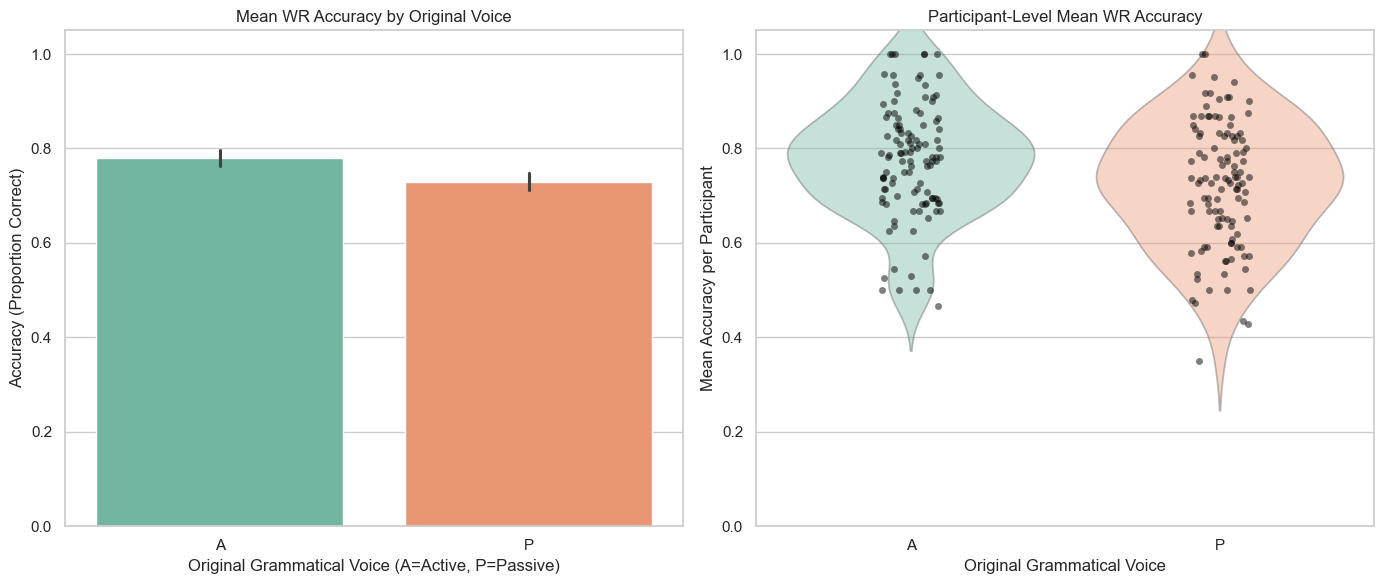

C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\384204123.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\384204123.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


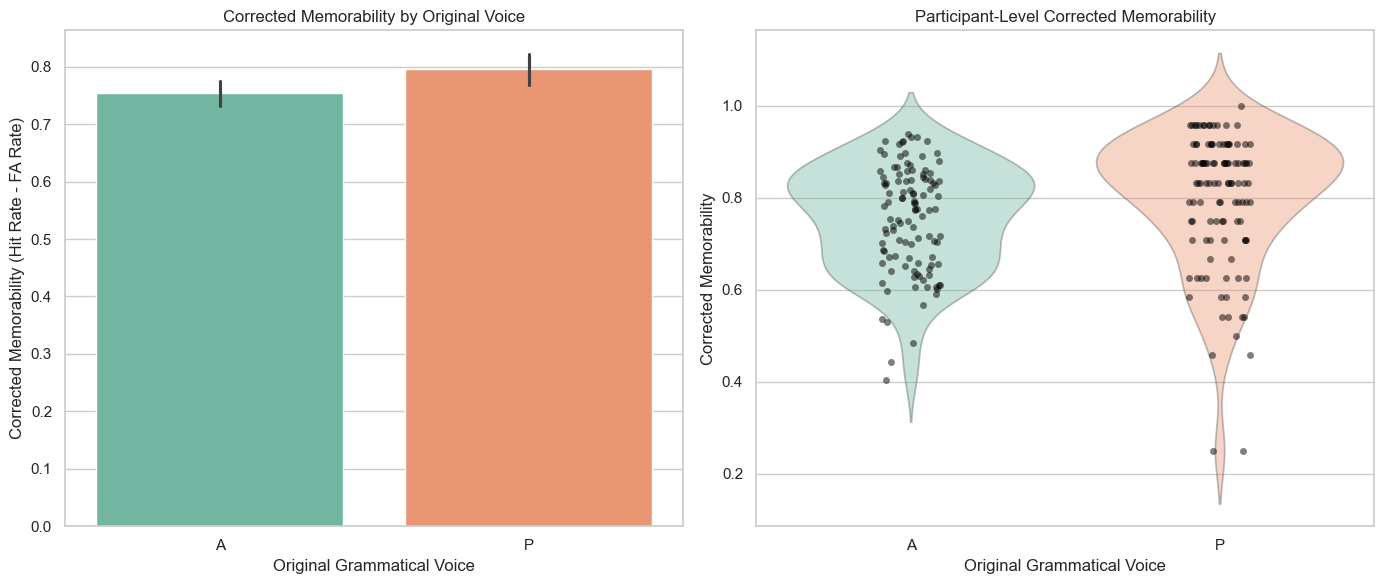

In [6]:
# --- Figure 1: Bar plot + Violin plot of WR Accuracy ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x='Original_Voice', y='Accuracy WR', data=analysis_df,
    errorbar='ci', palette='Set2', order=['A', 'P'], ax=axes[0]
)
axes[0].set_title('Mean WR Accuracy by Original Voice')
axes[0].set_xlabel('Original Grammatical Voice (A=Active, P=Passive)')
axes[0].set_ylabel('Accuracy (Proportion Correct)')
axes[0].set_ylim(0, 1.05)

participant_means = analysis_df.groupby(['participant_ID', 'Original_Voice'])['Accuracy WR'].mean().reset_index()

sns.violinplot(
    x='Original_Voice', y='Accuracy WR', data=participant_means,
    palette='Set2', order=['A', 'P'], inner=None, alpha=0.4, ax=axes[1]
)
sns.stripplot(
    x='Original_Voice', y='Accuracy WR', data=participant_means,
    color='black', alpha=0.5, order=['A', 'P'], jitter=True, ax=axes[1]
)
axes[1].set_title('Participant-Level Mean WR Accuracy')
axes[1].set_xlabel('Original Grammatical Voice')
axes[1].set_ylabel('Mean Accuracy per Participant')
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# --- Figure 2: Corrected Memorability distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x='Original_Voice', y='corrected_memorability',
    data=analysis_df.groupby(['participant_ID', 'Original_Voice'])['corrected_memorability'].first().reset_index(),
    errorbar='ci', palette='Set2', order=['A', 'P'], ax=axes[0]
)
axes[0].set_title('Corrected Memorability by Original Voice')
axes[0].set_xlabel('Original Grammatical Voice')
axes[0].set_ylabel('Corrected Memorability (Hit Rate - FA Rate)')

cm_participant = analysis_df.groupby(['participant_ID', 'Original_Voice'])['corrected_memorability'].first().reset_index()
sns.violinplot(
    x='Original_Voice', y='corrected_memorability', data=cm_participant,
    palette='Set2', order=['A', 'P'], inner=None, alpha=0.4, ax=axes[1]
)
sns.stripplot(
    x='Original_Voice', y='corrected_memorability', data=cm_participant,
    color='black', alpha=0.5, order=['A', 'P'], jitter=True, ax=axes[1]
)
axes[1].set_title('Participant-Level Corrected Memorability')
axes[1].set_xlabel('Original Grammatical Voice')
axes[1].set_ylabel('Corrected Memorability')
plt.tight_layout()
plt.show()

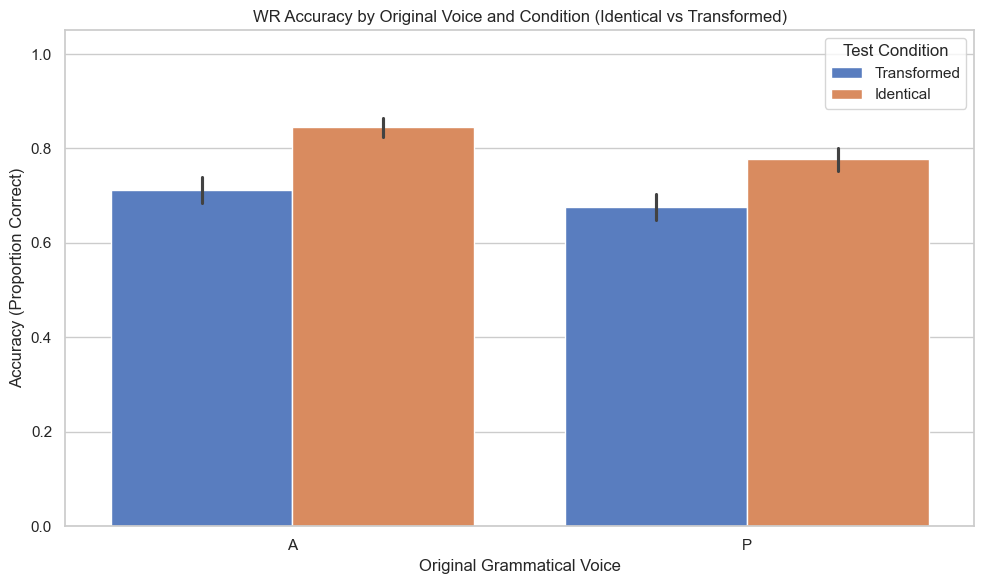

In [7]:
# --- Figure 2: Grouped bar plot - Voice x Condition interaction ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x='Original_Voice', y='Accuracy WR', hue='Condition',
    data=analysis_df, errorbar='ci', palette='muted', order=['A', 'P'], ax=ax
)
ax.set_title('WR Accuracy by Original Voice and Condition (Identical vs Transformed)')
ax.set_xlabel('Original Grammatical Voice')
ax.set_ylabel('Accuracy (Proportion Correct)')
ax.set_ylim(0, 1.05)
ax.legend(title='Test Condition')
plt.tight_layout()
plt.show()

## Normality Check and Statistical Analysis

Because the same participants contribute data to both Active and Passive conditions, we use a **paired (dependent-samples) pipeline**.

- Compute participant-level paired differences (Passive - Active)
- Check pair completeness (participants with both Active and Passive values)
- Check normality of paired differences using **Shapiro-Wilk**
- If differences are approximately normal (p >= 0.05) -> **paired t-test**
- Otherwise -> **Wilcoxon signed-rank test**

We also report a paired effect size (**Cohen's d_z**) for each analysis.

### Why Pairing Is Used Here

For Hypothesis 3, the comparison is **within participant** (not between different participant groups).

- Each participant contributes one WR score for **Active** and one WR score for **Passive**.
- These two values are linked because they come from the same person.
- The paired unit is therefore: `participant_ID` -> (`A`, `P`).

The analysis pipeline is:
1. Build participant-level pairs (`A`, `P`) and keep only complete pairs.
2. Compute the paired difference for each participant: `P - A`.
3. Test normality on these differences (Shapiro-Wilk).
4. If differences are approximately normal: use a **paired t-test**.
5. Otherwise: use a **Wilcoxon signed-rank test**.

Why this is correct:
- Paired tests account for within-person dependence and reduce person-level baseline noise.
- An independent-groups test (e.g., Mann-Whitney U or independent t-test) assumes observations are unrelated across groups, which is not true once both conditions come from the same participants.
- Descriptive trial counts can differ across conditions, but paired inference is based on matched participant pairs used in the test.

--- WR Accuracy Pair Completeness Check ---
Total participants in WR table: 112
Participants with both Active and Passive: 112
Participants dropped from paired test: 0

--- WR Accuracy Paired Summary ---
Active mean  = 0.7763, sd = 0.1221
Passive mean = 0.7231, sd = 0.1343
Mean difference (P - A) = -0.0531

--- Shapiro-Wilk test (WR paired differences) ---
W = 0.9890, p = 0.4999
Differences normal? Yes

--- Corrected Memorability Pair Completeness Check ---
Total participants in CM table: 112
Participants with both Active and Passive: 112
Participants dropped from paired test: 0

--- Corrected Memorability Paired Summary ---
Active mean  = 0.7547, sd = 0.1154
Passive mean = 0.7961, sd = 0.1479
Mean difference (P - A) = 0.0414

--- Shapiro-Wilk test (CM paired differences) ---
W = 0.9863, p = 0.3106
Differences normal? Yes


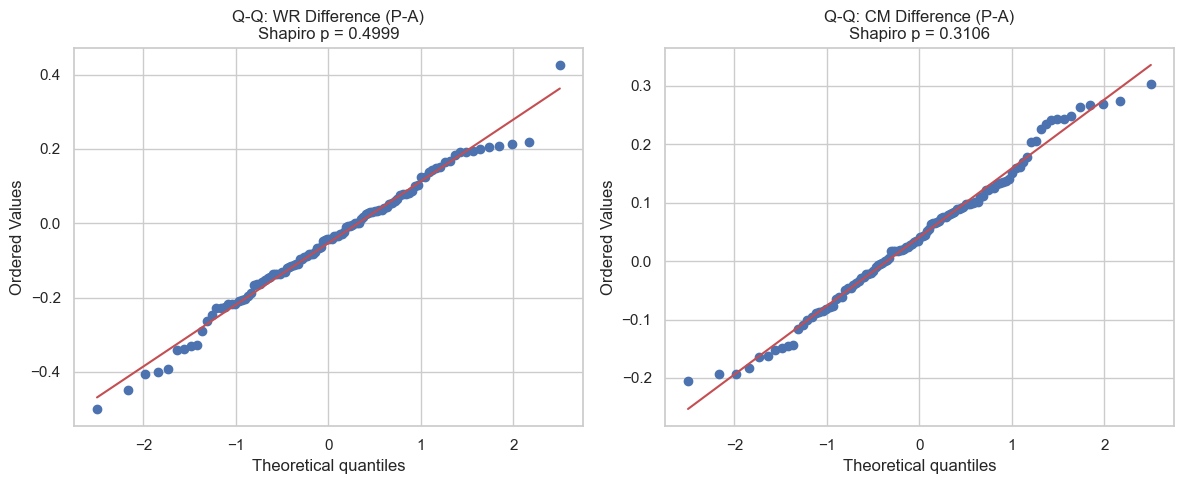


WR paired differences are normal -> using paired t-test
t-statistic = -3.4112
p-value     = 0.0009
Cohen's d_z (P - A) = -0.3223

CM paired differences are normal -> using paired t-test
t-statistic = 3.7607
p-value     = 0.0003
Cohen's d_z (P - A) = 0.3554

=== Interpretation (alpha = 0.05) ===

WR Accuracy (Paired t-test):
  Significant difference found (p = 0.0009).
  Passive accuracy is lower than Active accuracy.
  This CONTRADICTS the hypothesis.

Corrected Memorability (Paired t-test):
  Significant difference found (p = 0.0003).
  Passive corrected memorability is higher than Active.


In [8]:
# ======================================================================
# Normality Check -> Choose Parametric vs Non-Parametric Test (PAIRED)
# ======================================================================

alpha = 0.05

# --- 1. WR Accuracy: paired data (Passive vs Active within participant) ---
wr_wide = participant_means.pivot(
    index='participant_ID', columns='Original_Voice', values='Accuracy WR'
)
wr_total = len(wr_wide)
wr_paired = wr_wide.dropna()
wr_dropped = wr_total - len(wr_paired)

print('--- WR Accuracy Pair Completeness Check ---')
print(f'Total participants in WR table: {wr_total}')
print(f'Participants with both Active and Passive: {len(wr_paired)}')
print(f'Participants dropped from paired test: {wr_dropped}')

if wr_dropped > 0:
    print('Note: Paired tests use only matched participants with both conditions.')

diff_wr = wr_paired['P'] - wr_paired['A']

print('\n--- WR Accuracy Paired Summary ---')
print(f'Active mean  = {wr_paired["A"].mean():.4f}, sd = {wr_paired["A"].std(ddof=1):.4f}')
print(f'Passive mean = {wr_paired["P"].mean():.4f}, sd = {wr_paired["P"].std(ddof=1):.4f}')
print(f'Mean difference (P - A) = {diff_wr.mean():.4f}')

sw_wr_stat, sw_wr_p = stats.shapiro(diff_wr)
print('\n--- Shapiro-Wilk test (WR paired differences) ---')
print(f'W = {sw_wr_stat:.4f}, p = {sw_wr_p:.4f}')
wr_diff_normal = sw_wr_p >= alpha
print(f'Differences normal? {"Yes" if wr_diff_normal else "No"}')

# --- 2. Corrected Memorability: paired data (Passive vs Active within participant) ---
cm_df = analysis_df.groupby(['participant_ID', 'Original_Voice'])['corrected_memorability'].first().reset_index()
cm_wide = cm_df.pivot(
    index='participant_ID', columns='Original_Voice', values='corrected_memorability'
)
cm_total = len(cm_wide)
cm_paired = cm_wide.dropna()
cm_dropped = cm_total - len(cm_paired)

print('\n--- Corrected Memorability Pair Completeness Check ---')
print(f'Total participants in CM table: {cm_total}')
print(f'Participants with both Active and Passive: {len(cm_paired)}')
print(f'Participants dropped from paired test: {cm_dropped}')

if cm_dropped > 0:
    print('Note: Paired tests use only matched participants with both conditions.')

diff_cm = cm_paired['P'] - cm_paired['A']

print('\n--- Corrected Memorability Paired Summary ---')
print(f'Active mean  = {cm_paired["A"].mean():.4f}, sd = {cm_paired["A"].std(ddof=1):.4f}')
print(f'Passive mean = {cm_paired["P"].mean():.4f}, sd = {cm_paired["P"].std(ddof=1):.4f}')
print(f'Mean difference (P - A) = {diff_cm.mean():.4f}')

sw_cm_stat, sw_cm_p = stats.shapiro(diff_cm)
print('\n--- Shapiro-Wilk test (CM paired differences) ---')
print(f'W = {sw_cm_stat:.4f}, p = {sw_cm_p:.4f}')
cm_diff_normal = sw_cm_p >= alpha
print(f'Differences normal? {"Yes" if cm_diff_normal else "No"}')

# --- Q-Q plots for paired differences ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(diff_wr, dist='norm', plot=axes[0])
axes[0].set_title(f'Q-Q: WR Difference (P-A)\nShapiro p = {sw_wr_p:.4f}')
stats.probplot(diff_cm, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q: CM Difference (P-A)\nShapiro p = {sw_cm_p:.4f}')
plt.tight_layout()
plt.show()

# Helper: Cohen's dz for paired samples
def cohens_dz(diff):
    sd = diff.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return diff.mean() / sd

# ======================================================================
# WR Accuracy Test (chosen by normality of paired differences)
# ======================================================================
print(f'\n{"=" * 60}')
if wr_diff_normal:
    print('WR paired differences are normal -> using paired t-test')
    t_wr, p_wr = stats.ttest_rel(wr_paired['P'], wr_paired['A'])
    print(f't-statistic = {t_wr:.4f}')
    print(f'p-value     = {p_wr:.4f}')
    test_used_wr = 'Paired t-test'
else:
    print('WR paired differences are NOT normal -> using Wilcoxon signed-rank test')
    w_wr, p_wr = stats.wilcoxon(wr_paired['P'], wr_paired['A'])
    print(f'statistic = {w_wr:.4f}')
    print(f'p-value   = {p_wr:.4f}')
    test_used_wr = 'Wilcoxon signed-rank'

cohens_dz_wr = cohens_dz(diff_wr)
print(f"Cohen's d_z (P - A) = {cohens_dz_wr:.4f}")

# ======================================================================
# Corrected Memorability Test (chosen by normality of paired differences)
# ======================================================================
print(f'\n{"=" * 60}')
if cm_diff_normal:
    print('CM paired differences are normal -> using paired t-test')
    t_cm, p_cm = stats.ttest_rel(cm_paired['P'], cm_paired['A'])
    print(f't-statistic = {t_cm:.4f}')
    print(f'p-value     = {p_cm:.4f}')
    test_used_cm = 'Paired t-test'
else:
    print('CM paired differences are NOT normal -> using Wilcoxon signed-rank test')
    w_cm, p_cm = stats.wilcoxon(cm_paired['P'], cm_paired['A'])
    print(f'statistic = {w_cm:.4f}')
    print(f'p-value   = {p_cm:.4f}')
    test_used_cm = 'Wilcoxon signed-rank'

cohens_dz_cm = cohens_dz(diff_cm)
print(f"Cohen's d_z (P - A) = {cohens_dz_cm:.4f}")

# ======================================================================
# Interpretation
# ======================================================================
print(f'\n{"=" * 60}')
print(f'=== Interpretation (alpha = {alpha}) ===')
print(f'{"=" * 60}')

# WR Accuracy
print(f'\nWR Accuracy ({test_used_wr}):')
if p_wr < alpha:
    direction = 'higher' if wr_paired['P'].mean() > wr_paired['A'].mean() else 'lower'
    print(f'  Significant difference found (p = {p_wr:.4f}).')
    print(f'  Passive accuracy is {direction} than Active accuracy.')
    if direction == 'higher':
        print('  This SUPPORTS the hypothesis.')
    else:
        print('  This CONTRADICTS the hypothesis.')
else:
    print(f'  No significant difference found (p = {p_wr:.4f}).')

# Corrected Memorability
print(f'\nCorrected Memorability ({test_used_cm}):')
if p_cm < alpha:
    direction_cm = 'higher' if cm_paired['P'].mean() > cm_paired['A'].mean() else 'lower'
    print(f'  Significant difference found (p = {p_cm:.4f}).')
    print(f'  Passive corrected memorability is {direction_cm} than Active.')
else:
    print(f'  No significant difference found (p = {p_cm:.4f}).')

## Reaction Time Analysis: Active vs. Passive Voice

**Hypothesis:** Participants take longer to react to passive sentences than active sentences, because passive forms require more processing effort.

- **H₀:** There is no difference in reaction time between active and passive sentences.
- **H₁:** Reaction time differs between active and passive sentences.

We examine both **IR reaction time** (time to recognize the sentence as a repeat) and **WR reaction time** (time to judge whether the wording changed). Analysis uses the same Shapiro-Wilk → paired t-test / Wilcoxon signed-rank pipeline.

Repeat trials with valid IR RT: 7666
Unique participants: 112

=== IR Reaction Time by Original Voice ===
  Voice A: Mean = 1496.3 ms, SD = 258.4 ms, N = 112
  Voice P: Mean = 1736.0 ms, SD = 299.4 ms, N = 112

=== WR Reaction Time by Original Voice ===
  Voice A: Mean = 1050.0 ms, SD = 625.8 ms, N = 112
  Voice P: Mean = 1066.4 ms, SD = 522.4 ms, N = 112


C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\2972157676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Original_Voice', y='mean_ir_rt', data=rt_participant_ir,
C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\2972157676.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Original_Voice', y='mean_wr_rt', data=rt_participant_wr,


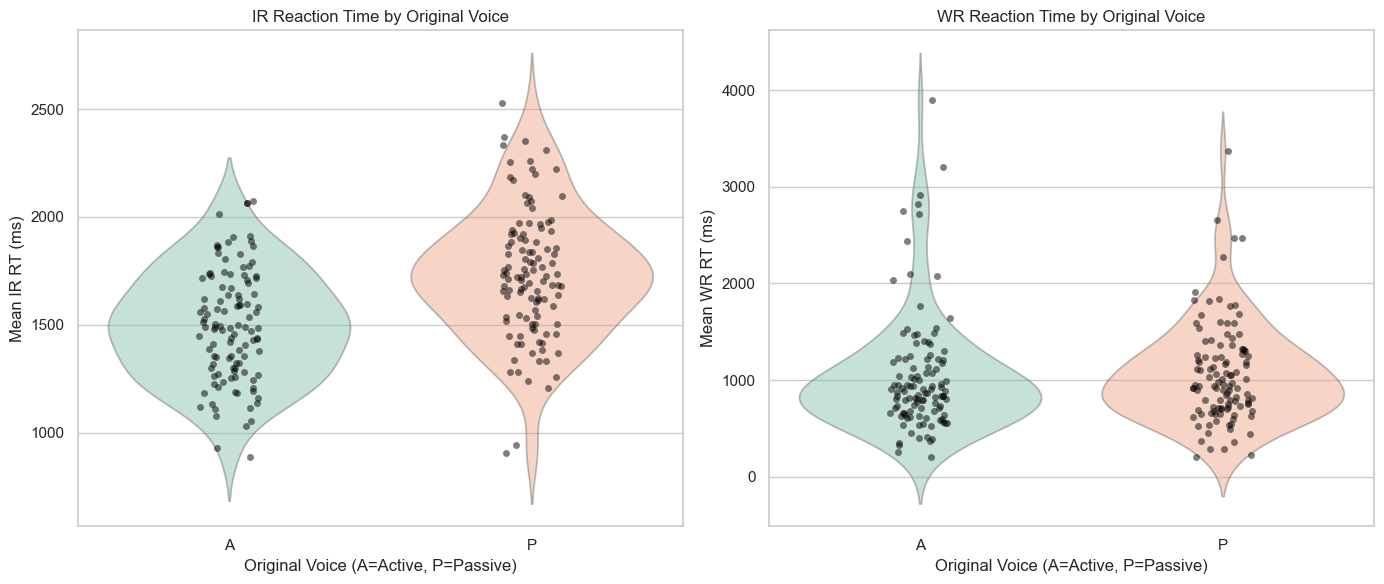

In [9]:
# ======================================================================
# Reaction Time Data Preparation
# ======================================================================

# Use repeat trials with valid Original Voice that have IR RT
rt_trials = voice_trials[
    voice_trials['is_repeat'] &
    voice_trials['ir_rt'].notna() &
    (voice_trials['ir_rt'] > 0)
].copy()

print(f'Repeat trials with valid IR RT: {len(rt_trials)}')
print(f'Unique participants: {rt_trials["participant_ID"].nunique()}')

# Per-participant mean IR RT by Original Voice
rt_participant_ir = rt_trials.groupby(
    ['participant_ID', 'Original_Voice']
)['ir_rt'].mean().reset_index()
rt_participant_ir.columns = ['participant_ID', 'Original_Voice', 'mean_ir_rt']

# Also get WR RT from analysis_df (repeat trials where WR was pressed)
rt_wr = analysis_df[
    analysis_df['Reaction_time_WR'].notna() &
    (analysis_df['Reaction_time_WR'] > 0)
].copy()

rt_participant_wr = rt_wr.groupby(
    ['participant_ID', 'Original_Voice']
)['Reaction_time_WR'].mean().reset_index()
rt_participant_wr.columns = ['participant_ID', 'Original_Voice', 'mean_wr_rt']

# --- Descriptive Statistics ---
print('\n=== IR Reaction Time by Original Voice ===')
for v in ['A', 'P']:
    sub = rt_participant_ir[rt_participant_ir['Original_Voice'] == v]
    print(f'  Voice {v}: Mean = {sub["mean_ir_rt"].mean():.1f} ms, '
          f'SD = {sub["mean_ir_rt"].std():.1f} ms, N = {len(sub)}')

print('\n=== WR Reaction Time by Original Voice ===')
for v in ['A', 'P']:
    sub = rt_participant_wr[rt_participant_wr['Original_Voice'] == v]
    print(f'  Voice {v}: Mean = {sub["mean_wr_rt"].mean():.1f} ms, '
          f'SD = {sub["mean_wr_rt"].std():.1f} ms, N = {len(sub)}')

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# IR RT
sns.violinplot(x='Original_Voice', y='mean_ir_rt', data=rt_participant_ir,
               palette='Set2', order=['A', 'P'], inner=None, alpha=0.4, ax=axes[0])
sns.stripplot(x='Original_Voice', y='mean_ir_rt', data=rt_participant_ir,
              color='black', alpha=0.5, order=['A', 'P'], jitter=True, ax=axes[0])
axes[0].set_title('IR Reaction Time by Original Voice')
axes[0].set_xlabel('Original Voice (A=Active, P=Passive)')
axes[0].set_ylabel('Mean IR RT (ms)')

# WR RT
sns.violinplot(x='Original_Voice', y='mean_wr_rt', data=rt_participant_wr,
               palette='Set2', order=['A', 'P'], inner=None, alpha=0.4, ax=axes[1])
sns.stripplot(x='Original_Voice', y='mean_wr_rt', data=rt_participant_wr,
              color='black', alpha=0.5, order=['A', 'P'], jitter=True, ax=axes[1])
axes[1].set_title('WR Reaction Time by Original Voice')
axes[1].set_xlabel('Original Voice (A=Active, P=Passive)')
axes[1].set_ylabel('Mean WR RT (ms)')

plt.tight_layout()
plt.show()

=== IR Reaction Time ===
Participants with both conditions: 112
Mean Active IR RT:  1496.3 ms
Mean Passive IR RT: 1736.0 ms
Mean difference (P - A): 239.7 ms

Shapiro-Wilk on IR RT differences: W = 0.9884, p = 0.4570
Normal? Yes

=== WR Reaction Time ===
Participants with both conditions: 112
Mean Active WR RT:  1050.0 ms
Mean Passive WR RT: 1066.4 ms
Mean difference (P - A): 16.4 ms

Shapiro-Wilk on WR RT differences: W = 0.8320, p = 0.0000
Normal? No


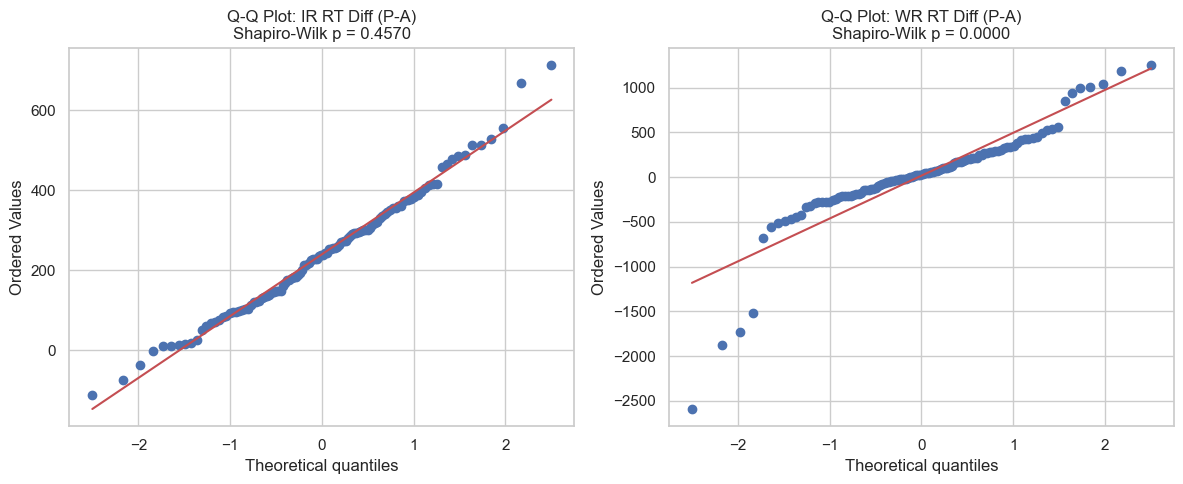


IR RT differences are normal → using Paired t-test
t-statistic = 16.5607
p-value     = 0.0000
Cohen's d = 1.5648

WR RT differences are NOT normal → using Wilcoxon Signed-Rank test
statistic = 2730.0000
p-value   = 0.2077
Cohen's d = 0.0315

=== Interpretation (alpha = 0.05) ===

IR Reaction Time (Paired t-test):
  Significant difference found (p = 0.0000).
  Passive IR RT is longer than Active IR RT.
  This SUPPORTS the hypothesis that passive sentences take longer to process.

WR Reaction Time (Wilcoxon Signed-Rank):
  No significant difference found (p = 0.2077).


In [10]:
# ======================================================================
# Normality Check and Statistical Test for Reaction Time
# ======================================================================
alpha = 0.05

# --- IR RT: Paired differences (P - A) ---
ir_pivot = rt_participant_ir.pivot(
    index='participant_ID', columns='Original_Voice', values='mean_ir_rt'
).dropna()
diff_ir_rt = ir_pivot['P'] - ir_pivot['A']

sw_ir_stat, sw_ir_p = stats.shapiro(diff_ir_rt)
ir_rt_normal = sw_ir_p >= 0.05
print(f'=== IR Reaction Time ===')
print(f'Participants with both conditions: {len(ir_pivot)}')
print(f'Mean Active IR RT:  {ir_pivot["A"].mean():.1f} ms')
print(f'Mean Passive IR RT: {ir_pivot["P"].mean():.1f} ms')
print(f'Mean difference (P - A): {diff_ir_rt.mean():.1f} ms')
print(f'\nShapiro-Wilk on IR RT differences: W = {sw_ir_stat:.4f}, p = {sw_ir_p:.4f}')
print(f'Normal? {"Yes" if ir_rt_normal else "No"}')

# --- WR RT: Paired differences (P - A) ---
wr_pivot = rt_participant_wr.pivot(
    index='participant_ID', columns='Original_Voice', values='mean_wr_rt'
).dropna()
diff_wr_rt = wr_pivot['P'] - wr_pivot['A']

sw_wr_rt_stat, sw_wr_rt_p = stats.shapiro(diff_wr_rt)
wr_rt_normal = sw_wr_rt_p >= 0.05
print(f'\n=== WR Reaction Time ===')
print(f'Participants with both conditions: {len(wr_pivot)}')
print(f'Mean Active WR RT:  {wr_pivot["A"].mean():.1f} ms')
print(f'Mean Passive WR RT: {wr_pivot["P"].mean():.1f} ms')
print(f'Mean difference (P - A): {diff_wr_rt.mean():.1f} ms')
print(f'\nShapiro-Wilk on WR RT differences: W = {sw_wr_rt_stat:.4f}, p = {sw_wr_rt_p:.4f}')
print(f'Normal? {"Yes" if wr_rt_normal else "No"}')

# --- Q-Q plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(diff_ir_rt, dist='norm', plot=axes[0])
axes[0].set_title(f'Q-Q Plot: IR RT Diff (P-A)\nShapiro-Wilk p = {sw_ir_p:.4f}')
stats.probplot(diff_wr_rt, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot: WR RT Diff (P-A)\nShapiro-Wilk p = {sw_wr_rt_p:.4f}')
plt.tight_layout()
plt.show()

# ======================================================================
# IR RT Test
# ======================================================================
print(f'\n{"="*60}')
if ir_rt_normal:
    print('IR RT differences are normal → using Paired t-test')
    t_ir, p_ir = stats.ttest_rel(ir_pivot['P'], ir_pivot['A'])
    print(f't-statistic = {t_ir:.4f}')
    print(f'p-value     = {p_ir:.4f}')
    test_ir = 'Paired t-test'
else:
    print('IR RT differences are NOT normal → using Wilcoxon Signed-Rank test')
    w_ir, p_ir = stats.wilcoxon(ir_pivot['P'], ir_pivot['A'])
    print(f'statistic = {w_ir:.4f}')
    print(f'p-value   = {p_ir:.4f}')
    test_ir = 'Wilcoxon Signed-Rank'

cohens_d_ir = diff_ir_rt.mean() / diff_ir_rt.std()
print(f"Cohen's d = {cohens_d_ir:.4f}")

# ======================================================================
# WR RT Test
# ======================================================================
print(f'\n{"="*60}')
if wr_rt_normal:
    print('WR RT differences are normal → using Paired t-test')
    t_wr_rt, p_wr_rt = stats.ttest_rel(wr_pivot['P'], wr_pivot['A'])
    print(f't-statistic = {t_wr_rt:.4f}')
    print(f'p-value     = {p_wr_rt:.4f}')
    test_wr_rt = 'Paired t-test'
else:
    print('WR RT differences are NOT normal → using Wilcoxon Signed-Rank test')
    w_wr_rt, p_wr_rt = stats.wilcoxon(wr_pivot['P'], wr_pivot['A'])
    print(f'statistic = {w_wr_rt:.4f}')
    print(f'p-value   = {p_wr_rt:.4f}')
    test_wr_rt = 'Wilcoxon Signed-Rank'

cohens_d_wr_rt = diff_wr_rt.mean() / diff_wr_rt.std()
print(f"Cohen's d = {cohens_d_wr_rt:.4f}")

# ======================================================================
# Interpretation
# ======================================================================
print(f'\n{"="*60}')
print(f'=== Interpretation (alpha = {alpha}) ===')
print(f'{"="*60}')

print(f'\nIR Reaction Time ({test_ir}):')
if p_ir < alpha:
    dir_ir = 'longer' if ir_pivot['P'].mean() > ir_pivot['A'].mean() else 'shorter'
    print(f'  Significant difference found (p = {p_ir:.4f}).')
    print(f'  Passive IR RT is {dir_ir} than Active IR RT.')
    if dir_ir == 'longer':
        print('  This SUPPORTS the hypothesis that passive sentences take longer to process.')
    else:
        print('  This CONTRADICTS the hypothesis.')
else:
    print(f'  No significant difference found (p = {p_ir:.4f}).')

print(f'\nWR Reaction Time ({test_wr_rt}):')
if p_wr_rt < alpha:
    dir_wr = 'longer' if wr_pivot['P'].mean() > wr_pivot['A'].mean() else 'shorter'
    print(f'  Significant difference found (p = {p_wr_rt:.4f}).')
    print(f'  Passive WR RT is {dir_wr} than Active WR RT.')
    if dir_wr == 'longer':
        print('  This SUPPORTS the hypothesis that passive sentences take longer to process.')
    else:
        print('  This CONTRADICTS the hypothesis.')
else:
    print(f'  No significant difference found (p = {p_wr_rt:.4f}).')

C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\3627255842.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Shubh\AppData\Local\Temp\ipykernel_18284\3627255842.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


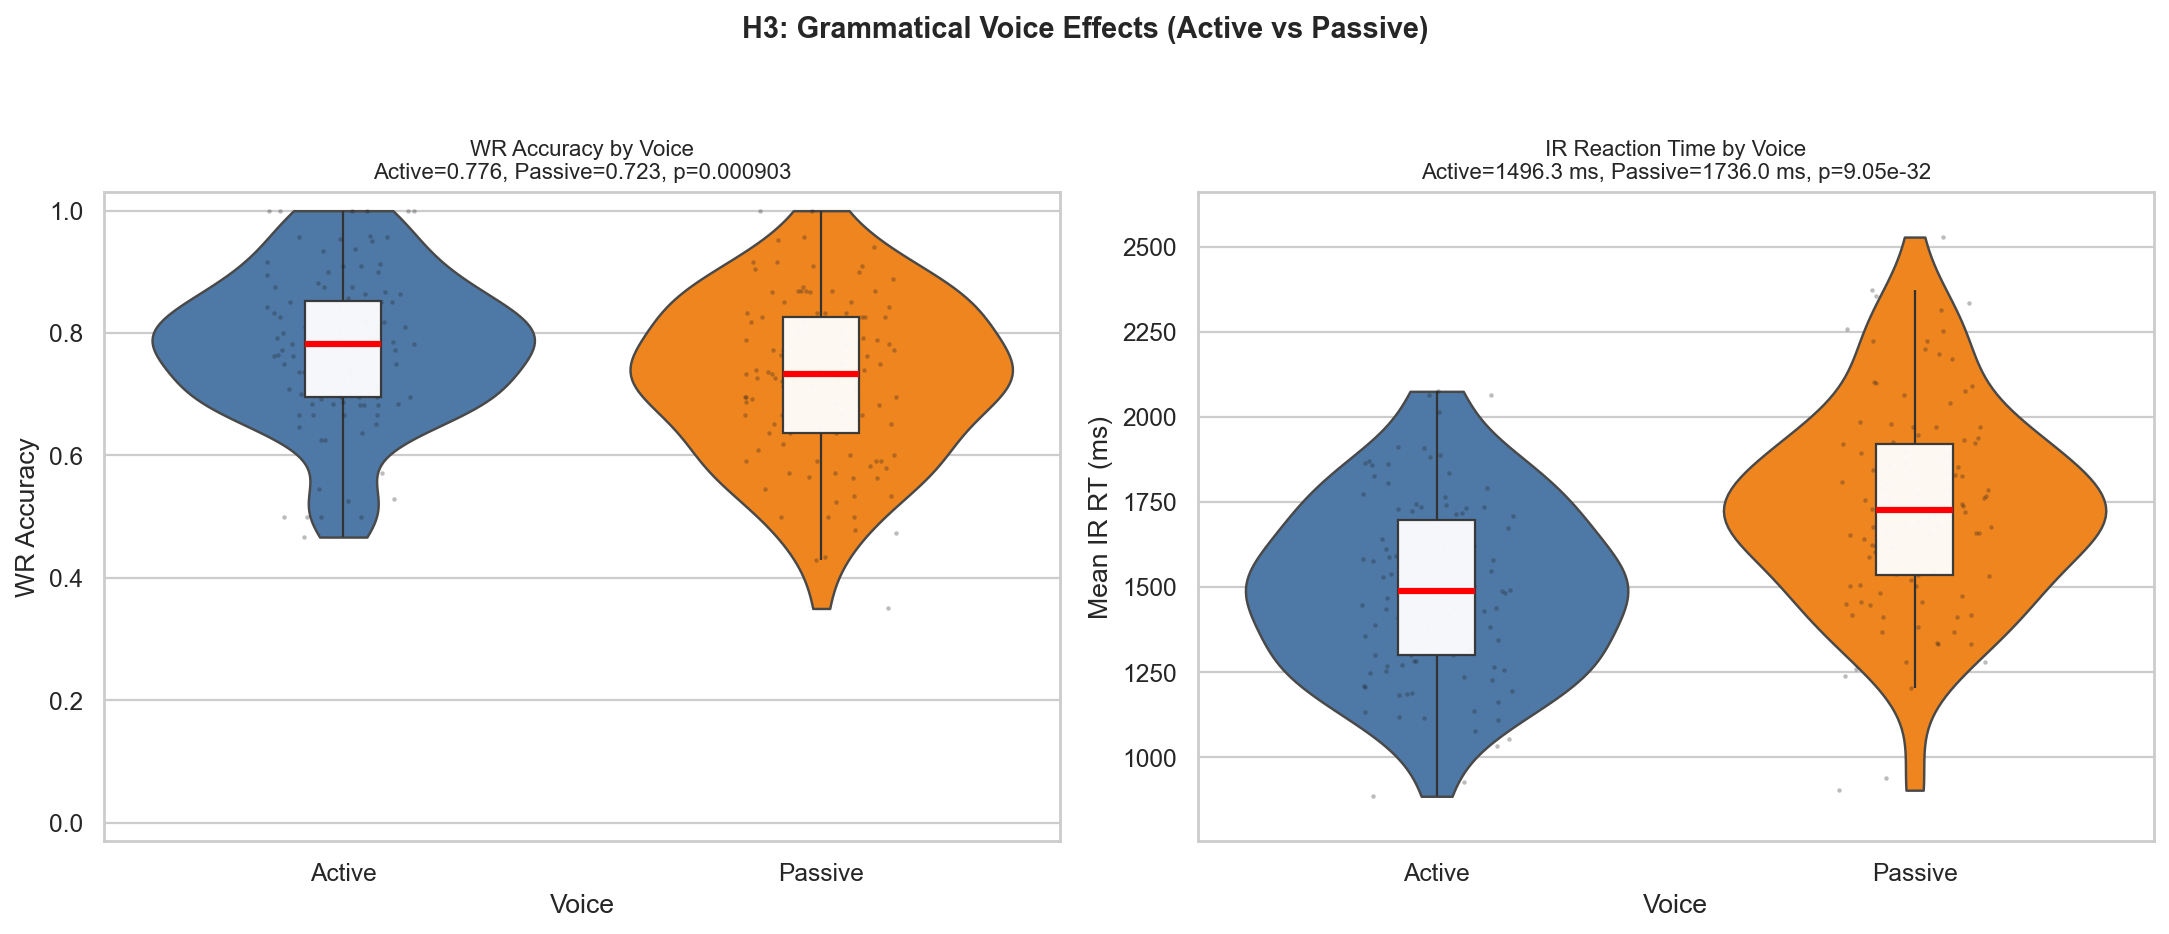

In [16]:
# Combined H3 figure with clipping + inner-box fixes
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Assumes these exist from earlier cells:
# wr_paired: participant-level WR accuracy wide table with columns A, P
# ir_pivot : participant-level IR RT wide table with columns A, P

# Long format
wr_long = (
    wr_paired[['A', 'P']]
    .rename(columns={'A': 'Active', 'P': 'Passive'})
    .melt(var_name='Voice', value_name='WR_Accuracy')
    .dropna()
)

rt_long = (
    ir_pivot[['A', 'P']]
    .rename(columns={'A': 'Active', 'P': 'Passive'})
    .melt(var_name='Voice', value_name='IR_RT_ms')
    .dropna()
)

# p-values for subtitle text
_, p_wr = stats.ttest_rel(wr_paired['A'], wr_paired['P'], nan_policy='omit')
_, p_rt = stats.ttest_rel(ir_pivot['A'], ir_pivot['P'], nan_policy='omit')

sns.set_theme(style='whitegrid', context='notebook')
order = ['Active', 'Passive']
palette = {'Active': '#4C78A8', 'Passive': '#F58518'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=160)

# ---------- Left: WR Accuracy ----------
sns.violinplot(
    data=wr_long, x='Voice', y='WR_Accuracy',
    order=order, palette=palette, inner=None, cut=0,
    linewidth=1.1, saturation=0.95, ax=axes[0]
)

# Cleaner inner box
sns.boxplot(
    data=wr_long, x='Voice', y='WR_Accuracy',
    order=order, width=0.16, showcaps=False, showfliers=False,
    boxprops={'facecolor': 'white', 'alpha': 0.95, 'edgecolor': '#333', 'linewidth': 1.0, 'zorder': 4},
    whiskerprops={'color': '#333', 'linewidth': 1.0},
    medianprops={'color': '#FF0000', 'linewidth': 2.8, 'alpha': 1.0, 'zorder': 8},
    ax=axes[0]
)

sns.stripplot(
    data=wr_long, x='Voice', y='WR_Accuracy',
    order=order, color='#222', alpha=0.30, size=2.0, jitter=0.16, ax=axes[0]
)

axes[0].set_title(
    f'WR Accuracy by Voice\nActive={wr_paired["A"].mean():.3f}, Passive={wr_paired["P"].mean():.3f}, p={p_wr:.3g}',
    fontsize=10
)
axes[0].set_xlabel('Voice')
axes[0].set_ylabel('WR Accuracy')
axes[0].set_ylim(-0.03, 1.03)  # avoids top/bottom clipping


# ---------- Right: IR Reaction Time ----------
sns.violinplot(
    data=rt_long, x='Voice', y='IR_RT_ms',
    order=order, palette=palette, inner=None, cut=0,
    linewidth=1.1, saturation=0.95, ax=axes[1]
)

sns.boxplot(
    data=rt_long, x='Voice', y='IR_RT_ms',
    order=order, width=0.16, showcaps=False, showfliers=False,
    boxprops={'facecolor': 'white', 'alpha': 0.95, 'edgecolor': '#333', 'linewidth': 1.0, 'zorder': 4},
    whiskerprops={'color': '#333', 'linewidth': 1.0},
    medianprops={'color': '#FF0000', 'linewidth': 2.8, 'alpha': 1.0, 'zorder': 8},
    ax=axes[1]
)

sns.stripplot(
    data=rt_long, x='Voice', y='IR_RT_ms',
    order=order, color='#222', alpha=0.30, size=2.0, jitter=0.16, ax=axes[1]
)

ymin, ymax = np.nanmin(rt_long['IR_RT_ms']), np.nanmax(rt_long['IR_RT_ms'])
ypad = (ymax - ymin) * 0.08 if ymax > ymin else 100
axes[1].set_ylim(ymin - ypad, ymax + ypad)  # avoids clipping
axes[1].set_title(
    f'IR Reaction Time by Voice\nActive={ir_pivot["A"].mean():.1f} ms, Passive={ir_pivot["P"].mean():.1f} ms, p={p_rt:.3g}',
    fontsize=10
)
axes[1].set_xlabel('Voice')
axes[1].set_ylabel('Mean IR RT (ms)')

fig.suptitle('H3: Grammatical Voice Effects (Active vs Passive)', fontsize=13, fontweight='bold', y=0.98)

# Better spacing so titles/labels do not get cut
plt.tight_layout(rect=[0.01, 0.01, 0.99, 0.94])
plt.show()